<a href="https://colab.research.google.com/github/Mbokade2004/Mbokade2004/blob/main/Naive_Bayes_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Confusion Matrix:
[[65  3]
 [ 7 25]]

Accuracy: 0.9

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.96      0.93        68
           1       0.89      0.78      0.83        32

    accuracy                           0.90       100
   macro avg       0.90      0.87      0.88       100
weighted avg       0.90      0.90      0.90       100



<ipython-input-2-492e194d693f>:55: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x_set[y_set == j, 0], x_set[y_set == j, 1],


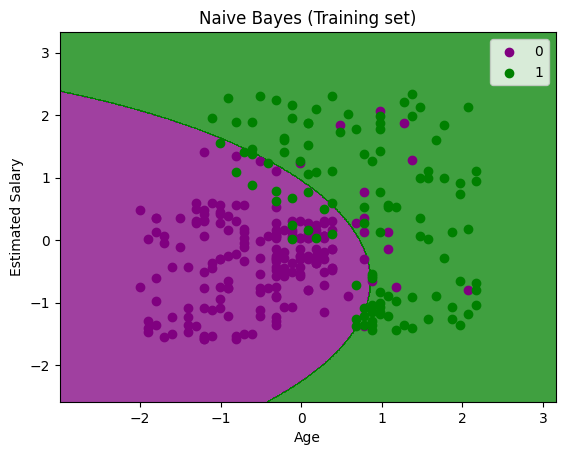

<ipython-input-2-492e194d693f>:76: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x_set[y_set == j, 0], x_set[y_set == j, 1],


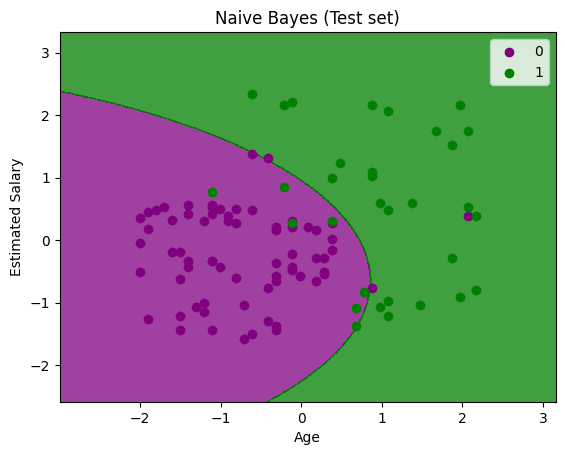

In [ ]:
# Importing libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# Step 1: Data Preprocessing
# Load dataset
dataset = pd.read_csv('User_Data (1).csv')

# Extracting features and target
X = dataset.iloc[:, [2, 3]].values  # Features: Age and Estimated Salary
y = dataset.iloc[:, 4].values       # Target: Purchased

# Splitting dataset into Training and Test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

# Feature Scaling
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# Step 2: Fitting Naïve Bayes Model
classifier = GaussianNB()
classifier.fit(X_train, y_train)

# Step 3: Predicting the Test Set Results
y_pred = classifier.predict(X_test)

# Step 4: Evaluating the Model with Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Step 5: Visualizing the Training Set Results
x_set, y_set = X_train, y_train
X1, X2 = np.meshgrid(
    np.arange(start=x_set[:, 0].min() - 1, stop=x_set[:, 0].max() + 1, step=0.01),
    np.arange(start=x_set[:, 1].min() - 1, stop=x_set[:, 1].max() + 1, step=0.01)
)
plt.contourf(
    X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
    alpha=0.75, cmap=ListedColormap(('purple', 'green'))
)
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(x_set[y_set == j, 0], x_set[y_set == j, 1],
                c=ListedColormap(('purple', 'green'))(i), label=j)
plt.title('Naive Bayes (Training set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

# Step 6: Visualizing the Test Set Results
x_set, y_set = X_test, y_test
X1, X2 = np.meshgrid(
    np.arange(start=x_set[:, 0].min() - 1, stop=x_set[:, 0].max() + 1, step=0.01),
    np.arange(start=x_set[:, 1].min() - 1, stop=x_set[:, 1].max() + 1, step=0.01)
)
plt.contourf(
    X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
    alpha=0.75, cmap=ListedColormap(('purple', 'green'))
)
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(x_set[y_set == j, 0], x_set[y_set == j, 1],
                c=ListedColormap(('purple', 'green'))(i), label=j)
plt.title('Naive Bayes (Test set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()


**Practice** **Problem**

---- Classification Results ----
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45


---- Regression Results ----
Mean Squared Error: 678.729


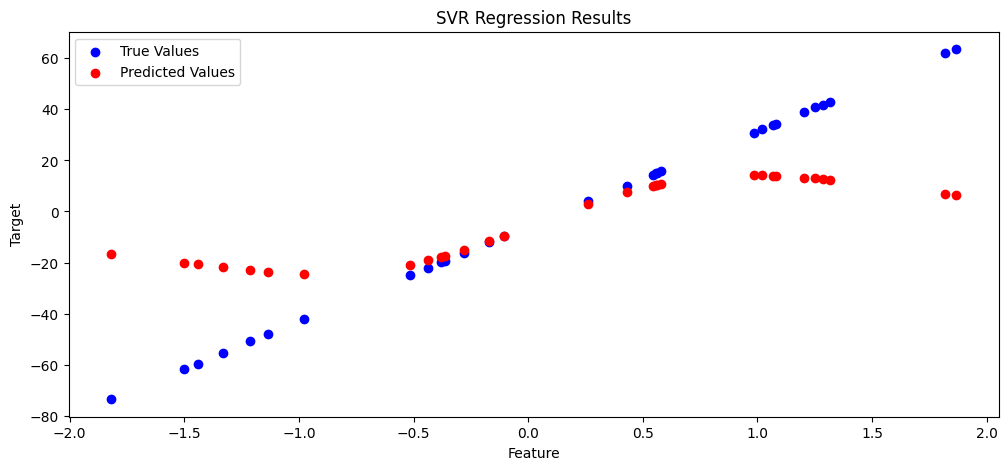

In [ ]:
# Import libraries
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris, make_regression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, SVR
from sklearn.metrics import classification_report, confusion_matrix, mean_squared_error
import matplotlib.pyplot as plt

# ----- PART 1: SVM FOR CLASSIFICATION -----

# Load Iris dataset
iris = load_iris()
X_class, y_class = iris.data, iris.target

# Split dataset
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class, y_class, test_size=0.3, random_state=42)

# Scale features
scaler_class = StandardScaler()
X_train_class = scaler_class.fit_transform(X_train_class)
X_test_class = scaler_class.transform(X_test_class)

# Train SVM for classification
svc_model = SVC(kernel='rbf', C=1, gamma='scale')
svc_model.fit(X_train_class, y_train_class)

# Predict and evaluate classification model
y_pred_class = svc_model.predict(X_test_class)
print("---- Classification Results ----")
print(confusion_matrix(y_test_class, y_pred_class))
print(classification_report(y_test_class, y_pred_class))

# ----- PART 2: SVM FOR REGRESSION -----

# Generate regression dataset
X_reg, y_reg = make_regression(n_samples=100, n_features=1, noise=0.1, random_state=42)

# Split dataset
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.3, random_state=42)

# Scale features
scaler_reg = StandardScaler()
X_train_reg = scaler_reg.fit_transform(X_train_reg)
X_test_reg = scaler_reg.transform(X_test_reg)

# Train SVM for regression
svr_model = SVR(kernel='rbf', C=1, epsilon=0.1)
svr_model.fit(X_train_reg, y_train_reg)

# Predict and evaluate regression model
y_pred_reg = svr_model.predict(X_test_reg)
mse = mean_squared_error(y_test_reg, y_pred_reg)
print("\n---- Regression Results ----")
print(f"Mean Squared Error: {mse:.3f}")

# ----- PART 3: VISUALIZATION -----

# Plot regression results
plt.figure(figsize=(12, 5))

# Original data
plt.scatter(X_test_reg, y_test_reg, color='blue', label='True Values')

# Predicted data
plt.scatter(X_test_reg, y_pred_reg, color='red', label='Predicted Values')

plt.title("SVR Regression Results")
plt.xlabel("Feature")
plt.ylabel("Target")
plt.legend()
plt.show()


---- Kernel SVM Results ----
[[36  2]
 [ 4 48]]
              precision    recall  f1-score   support

           0       0.90      0.95      0.92        38
           1       0.96      0.92      0.94        52

    accuracy                           0.93        90
   macro avg       0.93      0.94      0.93        90
weighted avg       0.93      0.93      0.93        90



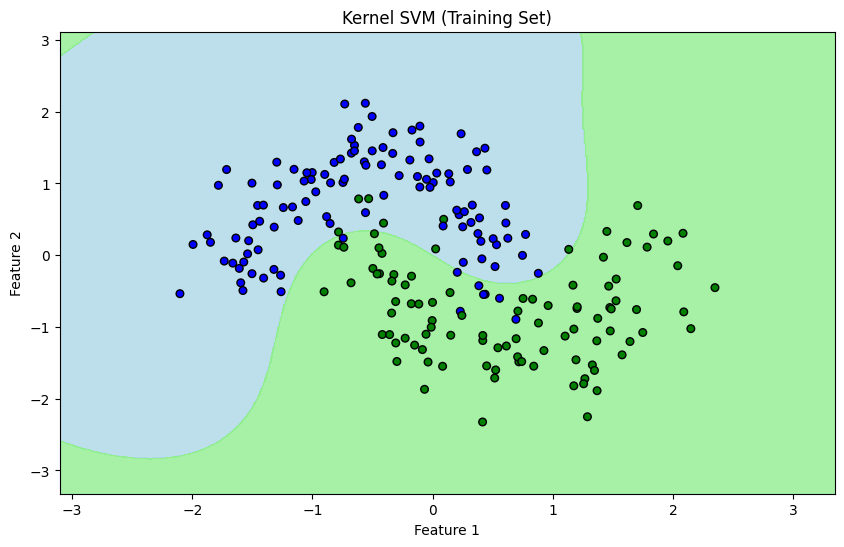

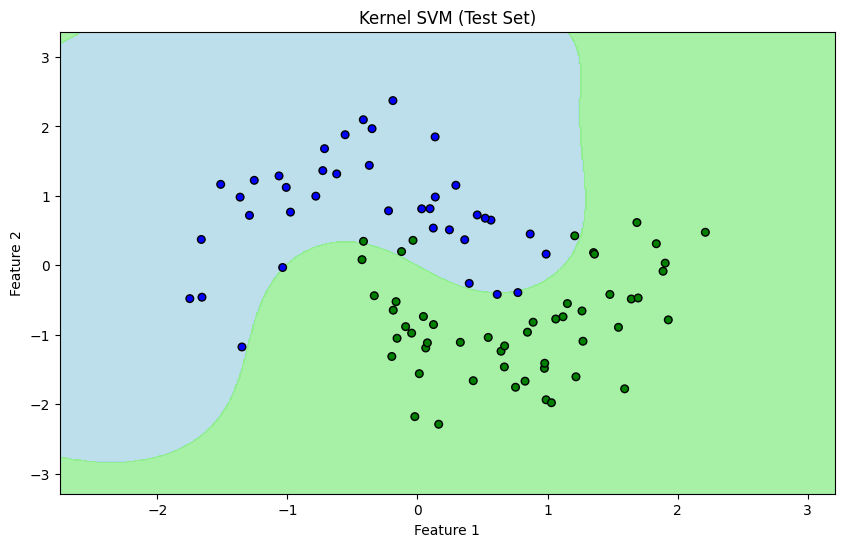

In [ ]:
# Import libraries
import numpy as np
import pandas as pd
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# ----- STEP 1: DATA PREPARATION -----

# Generate a non-linear dataset (e.g., make_moons dataset)
X, y = make_moons(n_samples=300, noise=0.2, random_state=42)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale the features (important for SVM)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ----- STEP 2: KERNEL SVM MODEL TRAINING -----

# Train the Kernel SVM with an RBF kernel
kernel_svm = SVC(kernel='rbf', C=1, gamma=0.5, random_state=42)
kernel_svm.fit(X_train, y_train)

# Predict the results
y_pred = kernel_svm.predict(X_test)

# ----- STEP 3: EVALUATION -----

# Evaluate the performance of the Kernel SVM
print("---- Kernel SVM Results ----")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# ----- STEP 4: VISUALIZATION -----

# Define a function to visualize decision boundaries
def plot_decision_boundaries(X, y, model, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=ListedColormap(('lightblue', 'lightgreen')))
    plt.scatter(X[:, 0], X[:, 1], c=y, s=30, edgecolor='k', cmap=ListedColormap(('blue', 'green')))
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

# Visualize decision boundary on training set
plot_decision_boundaries(X_train, y_train, kernel_svm, "Kernel SVM (Training Set)")

# Visualize decision boundary on test set
plot_decision_boundaries(X_test, y_test, kernel_svm, "Kernel SVM (Test Set)")

